# 08 — Feature Selection
Selects the best features from the pooled dataset using three complementary methods:
variance filtering, correlation pruning, mutual information, L1 logistic regression,
and Random Forest importance.  Outputs a `selected_features.json` used by notebook 09.

| # | Notebook | Reads → Writes |
|---|----------|----------------|
| 01 | Merge Raw Data | `raw/` → `merged/{coin}_5m_raw.parquet` |
| 02 | Clean & Label | `merged/` → `cleansed/{coin}_5m.parquet` |
| 03 | EDA | `cleansed/` |
| 03b | EDA — Downside Depegs | `cleansed/` |
| 04 | Feature Engineering | `cleansed/` → `features/{coin}_5m_features.parquet` |
| 05 | Build Pooled Dataset | `features/` → `features/pooled_5m.parquet` |
| 06 | Feature-Level EDA | `features/pooled_5m.parquet` |
| 07 | Depeg Event Study | `features/{coin}_5m_features.parquet` |
| **▶ 08** | **Feature Selection** | `features/pooled_5m.parquet` → `features/selected_features.json` |
| 09 | Baseline Models | `features/pooled_5m.parquet` + `selected_features.json` → model results |
| 10 | Final Model (CatBoost) | + `selected_features.json` → `data/models/nb10_catboost.cbm` + `nb10_meta.json` |
| 11 | Threshold & Ops | `data/models/nb10_meta.json` → threshold, alert metrics |
| 12 | LOEO Validation | `data/models/nb10_meta.json` → leave-one-event-out results |
### Selection pipeline
1. **Variance filter** — drop near-constant features (var < threshold)
2. **Correlation filter** — for each highly-correlated pair (|r| > 0.95), drop the member with lower mutual information
3. **Mutual information** — rank surviving features against both targets
4. **L1 Logistic Regression** — LASSO coefficient magnitudes (class-balanced, C=0.05)
5. **Random Forest** — impurity-based feature importance (200 trees, max_depth=8)
6. **Aggregate rank** — mean rank across methods; top N selected


In [1]:
import os
import sys
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── Environment detection ─────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Running in Google Colab — Drive mounted')
else:
    print('Running locally')


Running locally


In [2]:
DRIVE_PROJECT_PATH = 'MyDrive/Capstone'   # ← Colab: path inside Google Drive
LOCAL_PROJECT_PATH = None                 # ← Local: set explicit path or None for auto-detect

if IN_COLAB:
    ROOT = Path('/content/drive') / DRIVE_PROJECT_PATH
elif LOCAL_PROJECT_PATH is not None:
    ROOT = Path(LOCAL_PROJECT_PATH)
else:
    _candidates = [Path.cwd()] + list(Path.cwd().parents)
    ROOT = next((p for p in _candidates if (p / 'config' / 'settings.py').exists()), None)
    if ROOT is None:
        raise FileNotFoundError(
            'Could not find project root (looked for config/settings.py). '
            'Set LOCAL_PROJECT_PATH above or run from within the project directory.'
        )

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

FEATURES_DIR = ROOT / 'data' / 'processed' / 'features'

print(f'Project root:  {ROOT}')
print(f'Features dir:  {FEATURES_DIR}')


Project root:  /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global
Features dir:  /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/features


## 1. Configuration

In [3]:
TARGET_SYM   = 'depeg_next_4h_down'   # proxy for 24h — closest label in pooled parquet
TARGET_DOWN  = 'depeg_next_4h'         # symmetric counterpart
TRAIN_CUTOFF = '2025-01-01'           # use data before this date for selection

CORR_THRESHOLD     = 0.95    # drop one of each pair with |r| > this
SAMPLE_N           = 400_000 # max rows to use for MI / model-based methods
TOP_N_FEATURES     = 40      # final feature budget

# Features excluded from selection:
# - price_dev mean/absmax/lags: aggregate current peg state (leaky)
# - bars_above_*: count of bars already in depeg territory (leaky)
# - price_dev, price_dev_diff1, price_dev_std_*: kept — legitimate proximity signals (aligned with NB22)
# - raw stablecoin OHLCV: near-constant ~$1, no signal
# - raw BTC/ETH prices: ever-increasing trend, use return/z-score variants instead
EXCLUDE_PRICE_COLS = [
    c for c in [
        # rolling counts of bars above depeg threshold — leaky
        'bars_above_01pct_15min', 'bars_above_01pct_1h', 'bars_above_01pct_4h',
        'bars_above_03pct_15min', 'bars_above_03pct_1h', 'bars_above_03pct_4h',
        # rolling mean/absmax of price_dev — aggregate current peg state
        'price_dev_mean_15min', 'price_dev_mean_1h', 'price_dev_mean_4h',
        'price_dev_absmax_15min','price_dev_absmax_1h','price_dev_absmax_4h',
        # price_dev lags — redundant given price_dev + diff1
        'lag1_price_dev', 'lag3_price_dev', 'lag6_price_dev', 'lag12_price_dev',
        # cross-coin price deviations
        'cross_usdc_price_dev', 'cross_usdt_price_dev',
        # raw stablecoin OHLCV (near-constant; price ~$1 always)
        'coinapi_close', 'coinapi_open', 'coinapi_high', 'coinapi_low', 'coinapi_tick_count',
        'intrabar_range',
        # raw BTC/ETH prices — ever-increasing, use return/z-score variants instead
        'binance_btc_close', 'binance_eth_close',
        # daily macro rates — forward-filled to 5m, insufficient granularity for 5m depeg prediction
        't10y', 'dxy', 'fedfunds',
    ]
]

LABEL_COLS = [
    'depeg', 'depeg_down',
    'depeg_next_5min',  'depeg_next_5min_down',
    'depeg_next_30min', 'depeg_next_30min_down',
    'depeg_next_1h',    'depeg_next_1h_down',
    'depeg_next_4h',    'depeg_next_4h_down',
    'depeg_next_24h',   'depeg_next_24h_down',
]
META_COLS = ['coin_key', 'coin', 'date', 'time', 'peg', 'coin_type', 'coin_status']

print(f'Primary target   : {TARGET_SYM}  (proxy for 24h horizon used in NB17)')
print(f'Secondary target : {TARGET_DOWN}')
print(f'Train cutoff     : {TRAIN_CUTOFF}')
print(f'Feature budget   : top {TOP_N_FEATURES}')
print('Variance filter  : disabled (class imbalance — rare events have low overall variance)')

Primary target   : depeg_next_4h_down  (proxy for 24h horizon used in NB17)
Secondary target : depeg_next_4h
Train cutoff     : 2025-01-01
Feature budget   : top 40
Variance filter  : disabled (class imbalance — rare events have low overall variance)


## 2. Load Pooled Dataset

In [4]:
df = pd.read_parquet(FEATURES_DIR / 'pooled_5m.parquet')

# Cast nullable Int8 label columns → float64
for col in LABEL_COLS:
    if col in df.columns and pd.api.types.is_extension_array_dtype(df[col]):
        df[col] = df[col].astype('float64')

print(f'Loaded : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Index  : {df.index.min()} -> {df.index.max()}')
print(f'{TARGET_SYM} rate  : {df[TARGET_SYM].mean():.2%}')
print(f'{TARGET_DOWN} rate  : {df[TARGET_DOWN].mean():.2%}')


Loaded : 3,322,311 rows x 149 columns
Index  : 2017-08-17 04:05:00+00:00 -> 2026-02-27 23:55:00+00:00
depeg_next_4h_down rate  : 1.76%
depeg_next_4h rate  : 8.24%


## 3. Define Feature Set

In [5]:
excl = set(LABEL_COLS) | set(META_COLS) | set(EXCLUDE_PRICE_COLS)
feat_cols = sorted(set(df.columns) - excl)

print(f'Total columns     : {df.shape[1]}')
print(f'Excluded (label)  : {len(LABEL_COLS)}')
print(f'Excluded (meta)   : {len(META_COLS)}')
print(f'Feature columns   : {len(feat_cols)}')
print()
for f in feat_cols:
    print(f'  {f}')


Total columns     : 149
Excluded (label)  : 12
Excluded (meta)   : 7
Feature columns   : 101

  btc_drawdown_accel
  btc_return_1h
  btc_return_1h_zscore_30d
  btc_return_24h
  btc_return_4h
  btc_return_4h_zscore_30d
  btc_vol_1d
  btc_vol_4h
  burn_acc_1h
  burn_acc_zscore_1d
  burn_acc_zscore_30d
  burn_acc_zscore_7d
  burn_rate_ratio
  burn_sum_1h
  burn_sum_4h
  burn_vol_1h
  burn_vol_4h
  burn_vol_zscore_1d
  burn_vol_zscore_30d
  burn_vol_zscore_7d
  burn_zscore_1d
  burn_zscore_30d
  burn_zscore_7d
  curve_3pool_total_sell_sum_1h
  curve_3pool_total_sell_sum_4h
  curve_3pool_total_sell_zscore_30d
  curve_acc_1h
  curve_acc_zscore_1d
  curve_acc_zscore_30d
  curve_acc_zscore_7d
  curve_net_sell_sum_15min
  curve_net_sell_sum_1h
  curve_net_sell_sum_4h
  curve_net_sell_vol_1h
  curve_net_sell_vol_4h
  curve_net_sell_vol_zscore_1d
  curve_net_sell_vol_zscore_30d
  curve_net_sell_vol_zscore_7d
  curve_net_sell_zscore_1d
  curve_net_sell_zscore_30d
  curve_net_sell_zscore_7d
  curve

## 4. Train Window & Stratified Sample
All selection steps run on training data only (before `TRAIN_CUTOFF`) to prevent
look-ahead bias.  A stratified sample of `SAMPLE_N` rows is used for the
MI, L1, and RF steps to keep runtimes manageable.

In [6]:
train_mask = df.index < pd.Timestamp(TRAIN_CUTOFF, tz='UTC')
df_train   = df.loc[train_mask].dropna(subset=[TARGET_SYM, TARGET_DOWN]).copy()

print(f'Train rows         : {len(df_train):,}  ({len(df_train)/len(df):.1%} of full dataset)')
print(f'Train {TARGET_SYM} rate : {df_train[TARGET_SYM].mean():.2%}')
print(f'Train {TARGET_DOWN} rate : {df_train[TARGET_DOWN].mean():.2%}')

# Stratified subsample by TARGET_SYM to keep class ratio
if len(df_train) > SAMPLE_N:
    pos = df_train[df_train[TARGET_SYM] == 1]
    neg = df_train[df_train[TARGET_SYM] == 0]
    pos_n = int(SAMPLE_N * df_train[TARGET_SYM].mean())
    neg_n = SAMPLE_N - pos_n
    df_sel = pd.concat([
        pos.sample(n=min(pos_n, len(pos)), random_state=42),
        neg.sample(n=min(neg_n, len(neg)), random_state=42),
    ]).sort_index()
else:
    df_sel = df_train

print(f'\nSelection sample   : {len(df_sel):,} rows')
print(f'Sample depeg rate  : {df_sel[TARGET_SYM].mean():.2%}')

X_raw  = df_sel[feat_cols].copy()
y_sym  = df_sel[TARGET_SYM].values
y_down = df_sel[TARGET_DOWN].values


Train rows         : 2,739,112  (82.4% of full dataset)
Train depeg_next_4h_down rate : 2.13%
Train depeg_next_4h rate : 9.98%



Selection sample   : 400,000 rows
Sample depeg rate  : 2.13%


## 5. Imputation
Fill NaN with 0.  For rolling sum/z-score features this is appropriate:
z-scores are centered at 0 (normal activity), and sum features have no
activity when a coin has no on-chain events in a window.

In [7]:
imputer = SimpleImputer(strategy='constant', fill_value=0.0)
X_imp = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=feat_cols,
    index=X_raw.index,
)
print(f'NaN remaining after imputation: {X_imp.isna().sum().sum()}')
print(f'Shape: {X_imp.shape}')


NaN remaining after imputation: 0
Shape: (400000, 101)


## 6. Step 1 — Variance Filter
Drop features where variance < `VARIANCE_THRESHOLD`.  Near-constant columns
carry no signal and can destabilise model training.

In [8]:
# Variance filter disabled: with ~38:1 class imbalance, features that signal
# rare depeg events may have near-zero overall variance but high minority-class
# discriminative power. Skipping to avoid discarding genuine signals.
feat_var = feat_cols
print(f'Variance filter: skipped — using all {len(feat_var)} features')


Variance filter: skipped — using all 101 features


## 7. Step 2 — Correlation Filter
For each pair of features with |r| > `CORR_THRESHOLD`, drop the one with
lower mutual information against the primary target.

In [9]:
# Compute preliminary MI to break ties
mi_prelim = mutual_info_classif(
    X_imp[feat_var], y_sym, discrete_features=False, random_state=42
)
mi_prelim_s = pd.Series(mi_prelim, index=feat_var)

# Upper-triangle of absolute correlation matrix
corr_mat = X_imp[feat_var].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

to_drop_corr = set()
for col in upper.columns:
    high_partners = upper[col][upper[col] > CORR_THRESHOLD].index.tolist()
    for partner in high_partners:
        if col in to_drop_corr or partner in to_drop_corr:
            continue
        # Drop the one with lower preliminary MI
        if mi_prelim_s[col] >= mi_prelim_s[partner]:
            to_drop_corr.add(partner)
        else:
            to_drop_corr.add(col)

feat_uncorr = [f for f in feat_var if f not in to_drop_corr]
print(f'Correlation filter: {len(feat_var)} -> {len(feat_uncorr)} features (dropped {len(to_drop_corr)})')
if to_drop_corr:
    print(f'  Dropped: {sorted(to_drop_corr)}')


Correlation filter: 101 -> 99 features (dropped 2)
  Dropped: ['burn_sum_4h', 'fear_greed_level']


## 8. Step 3 — Mutual Information
Rank surviving features by mutual information with both targets.
Higher MI = more non-linear dependence between feature and label.

In [10]:
mi_sym_vals  = mutual_info_classif(
    X_imp[feat_uncorr], y_sym,  discrete_features=False, random_state=42
)
mi_down_vals = mutual_info_classif(
    X_imp[feat_uncorr], y_down, discrete_features=False, random_state=42
)

mi_df = pd.DataFrame({
    'feature':  feat_uncorr,
    'mi_sym':   mi_sym_vals,
    'mi_down':  mi_down_vals,
    'mi_avg':   (mi_sym_vals + mi_down_vals) / 2,
}).sort_values('mi_avg', ascending=False).reset_index(drop=True)

print(f'Top 20 features by mutual information (avg of both targets):')
display(
    mi_df.head(20)
    .style.format('{:.4f}', subset=['mi_sym', 'mi_down', 'mi_avg'])
    .bar(subset=['mi_avg'], color='#1565C0', vmin=0)
)


Top 20 features by mutual information (avg of both targets):


,feature,mi_sym,mi_down,mi_avg
0,price_dev,0.0859,0.2637,0.1748
1,vix,0.0500,0.1563,0.1032
2,net_flow_zscore_30d,0.0523,0.1391,0.0957
3,price_dev_std_4h,0.0311,0.1547,0.0929
4,net_flow_zscore_7d,0.0458,0.1262,0.0860
5,price_dev_std_1h,0.0316,0.1305,0.0810
6,net_flow_vol_zscore_30d,0.0483,0.1024,0.0754
7,net_flow_sum_1d,0.0335,0.1162,0.0749
8,burn_zscore_30d,0.0285,0.1140,0.0712
9,is_pre_curve,0.0404,0.0985,0.0694


## 9. Step 4 — L1 Logistic Regression
LASSO (C=0.05) with balanced class weights.  Features with non-zero coefficient
survived the sparsity penalty — a conservative filter for linearly useful signals.

In [11]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imp[feat_uncorr])

lr = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.05,
    class_weight='balanced', max_iter=1000, random_state=42
)
lr.fit(X_scaled, y_sym)

lr_df = pd.DataFrame({
    'feature': feat_uncorr,
    'lr_coef': np.abs(lr.coef_[0]),
}).sort_values('lr_coef', ascending=False).reset_index(drop=True)

lr_selected = lr_df[lr_df['lr_coef'] > 0]['feature'].tolist()
print(f'L1 LogReg: {len(lr_selected)} features with non-zero coefficient (out of {len(feat_uncorr)})')
display(
    lr_df.head(20)
    .style.format('{:.4f}', subset=['lr_coef'])
    .bar(subset=['lr_coef'], color='#C62828', vmin=0)
)


L1 LogReg: 85 features with non-zero coefficient (out of 99)


,feature,lr_coef
0,price_dev,3.7335
1,price_dev_std_4h,2.5741
2,burn_vol_4h,2.2056
3,burn_sum_1h,1.1352
4,burn_vol_1h,0.9766
5,burn_rate_ratio,0.8234
6,curve_net_sell_vol_4h,0.5934
7,mint_sum_1h,0.5617
8,curve_sell_buy_ratio_1h,0.5235
9,is_pre_curve,0.5036


## 10. Step 5 — Random Forest Importance
Gini-based feature importance from 200 trees.  Captures non-linear interactions
and is robust to feature scale.

In [12]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf.fit(X_imp[feat_uncorr], y_sym)

rf_df = pd.DataFrame({
    'feature': feat_uncorr,
    'rf_imp':  rf.feature_importances_,
}).sort_values('rf_imp', ascending=False).reset_index(drop=True)

print('Top 20 features by Random Forest importance:')
display(
    rf_df.head(20)
    .style.format('{:.4f}', subset=['rf_imp'])
    .bar(subset=['rf_imp'], color='#2E7D32', vmin=0)
)


Top 20 features by Random Forest importance:


,feature,rf_imp
0,price_dev,0.2733
1,price_dev_std_4h,0.1049
2,is_pre_curve,0.0623
3,burn_zscore_30d,0.0613
4,price_dev_std_1h,0.0585
5,burn_vol_zscore_30d,0.0389
6,burn_zscore_7d,0.0379
7,mint_zscore_30d,0.0346
8,mint_zscore_7d,0.0245
9,curve_3pool_total_sell_sum_4h,0.0237


## 11. Aggregate Rankings
Each method produces a rank for every feature.  The **mean rank** across all
three methods gives a stable, consensus-based ordering.

In [13]:
rank_df = (
    mi_df.set_index('feature')[['mi_avg']]
    .join(lr_df.set_index('feature')[['lr_coef']])
    .join(rf_df.set_index('feature')[['rf_imp']])
)

rank_df['rank_mi']   = rank_df['mi_avg'].rank(ascending=False)
rank_df['rank_lr']   = rank_df['lr_coef'].rank(ascending=False)
rank_df['rank_rf']   = rank_df['rf_imp'].rank(ascending=False)
rank_df['rank_mean'] = rank_df[['rank_mi', 'rank_lr', 'rank_rf']].mean(axis=1)
rank_df = rank_df.sort_values('rank_mean')

selected_features = rank_df.head(TOP_N_FEATURES).index.tolist()

print(f'Selected {len(selected_features)} features (top {TOP_N_FEATURES} by mean rank across MI / LR / RF):')
display(
    rank_df.head(TOP_N_FEATURES)[['rank_mi', 'rank_lr', 'rank_rf', 'rank_mean']]
    .style.format('{:.1f}')
    .background_gradient(cmap='RdYlGn_r', subset=['rank_mean'], vmin=1, vmax=len(feat_uncorr))
)


Selected 40 features (top 40 by mean rank across MI / LR / RF):


,rank_mi,rank_lr,rank_rf,rank_mean
feature,,,,
price_dev,1.0,1.0,1.0,1.0
price_dev_std_4h,4.0,2.0,2.0,2.7
is_pre_curve,10.0,10.0,3.0,7.7
price_dev_std_1h,6.0,15.0,5.0,8.7
vix,2.0,18.0,24.0,14.7
curve_net_sell_vol_4h,26.0,7.0,13.0,15.3
mint_zscore_30d,16.0,26.0,8.0,16.7
price_dev_std_15min,17.0,25.0,18.0,20.0
net_flow_vol_4h,30.0,20.0,11.0,20.3


## 12. Visualize

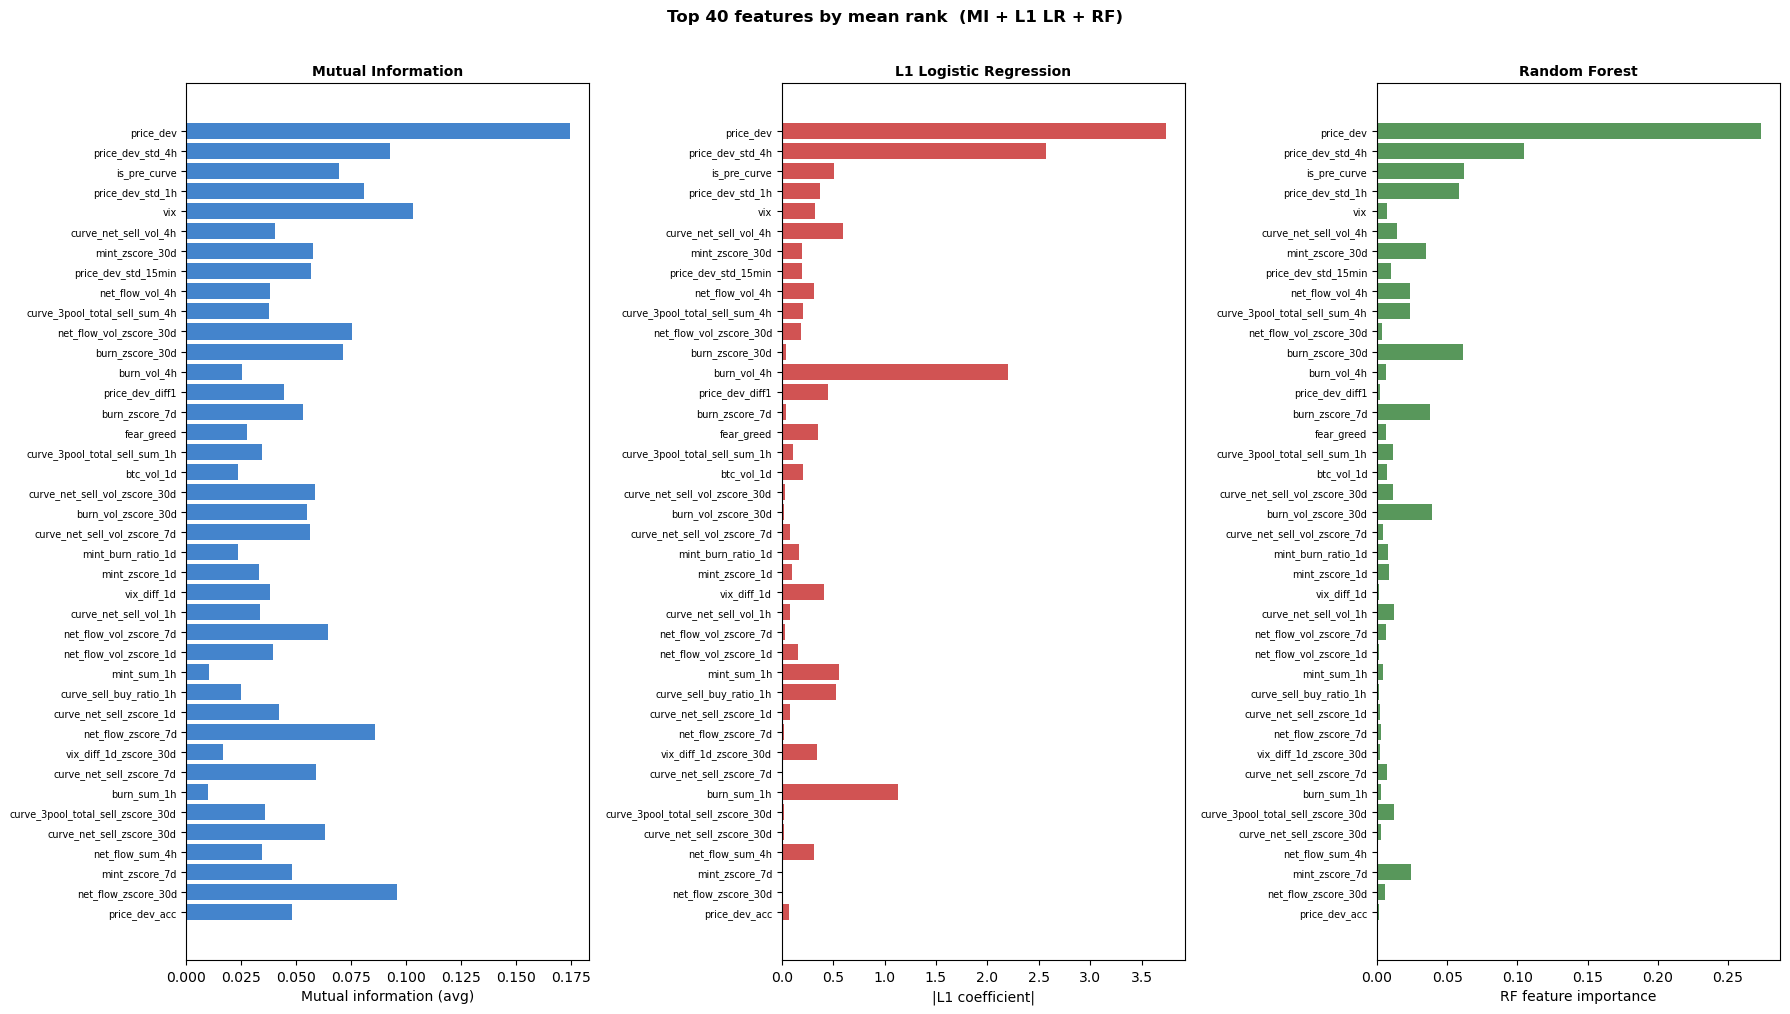

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, max(8, TOP_N_FEATURES // 4)))

top_feats = selected_features

# Panel 1: Mutual information
ax = axes[0]
vals = mi_df.set_index('feature').loc[top_feats, 'mi_avg']
ax.barh(range(len(top_feats)), vals.values[::-1], color='#1565C0', alpha=0.8)
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats[::-1], fontsize=7)
ax.set_xlabel('Mutual information (avg)')
ax.set_title('Mutual Information', fontsize=10, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.4)

# Panel 2: L1 LogReg coefficient
ax = axes[1]
vals = lr_df.set_index('feature').reindex(top_feats)['lr_coef'].fillna(0)
ax.barh(range(len(top_feats)), vals.values[::-1], color='#C62828', alpha=0.8)
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats[::-1], fontsize=7)
ax.set_xlabel('|L1 coefficient|')
ax.set_title('L1 Logistic Regression', fontsize=10, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.4)

# Panel 3: RF importance
ax = axes[2]
vals = rf_df.set_index('feature').reindex(top_feats)['rf_imp'].fillna(0)
ax.barh(range(len(top_feats)), vals.values[::-1], color='#2E7D32', alpha=0.8)
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats[::-1], fontsize=7)
ax.set_xlabel('RF feature importance')
ax.set_title('Random Forest', fontsize=10, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.4)

plt.suptitle(
    f'Top {TOP_N_FEATURES} features by mean rank  (MI + L1 LR + RF)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


## 13. Signal Group Summary
Count how many selected features come from each signal category.  This
validates whether on-chain and Curve signals survived data-driven selection.

In [15]:
GROUPS = {
    'Price / returns':    lambda f: any(k in f for k in ['price', 'return', 'close', 'vol']),
    'Net flow (on-chain)':lambda f: 'net_flow' in f or 'mint' in f or 'burn' in f or 'treasury' in f or 'sol_' in f or 'xrpl_' in f,
    'Curve DEX':          lambda f: 'curve' in f,
    'Market (BTC/ETH)':   lambda f: any(k in f for k in ['btc_', 'eth_', 'fear_greed']),
    'Macro (FRED)':       lambda f: any(k in f for k in ['dxy', 'vix', 't10y', 'fedfunds']),
    'Other':              lambda f: True,
}

group_counts = {}
assigned = set()
for grp, fn in GROUPS.items():
    members = [f for f in selected_features if f not in assigned and fn(f)]
    group_counts[grp] = members
    assigned.update(members)

print(f'Selected {len(selected_features)} features by signal group:\n')
for grp, members in group_counts.items():
    if members:
        print(f'  {grp} ({len(members)})')
        for m in sorted(members):
            print(f'    {m}')


Selected 40 features by signal group:

  Price / returns (17)
    btc_vol_1d
    burn_vol_4h
    burn_vol_zscore_30d
    curve_net_sell_vol_1h
    curve_net_sell_vol_4h
    curve_net_sell_vol_zscore_30d
    curve_net_sell_vol_zscore_7d
    net_flow_vol_4h
    net_flow_vol_zscore_1d
    net_flow_vol_zscore_30d
    net_flow_vol_zscore_7d
    price_dev
    price_dev_acc
    price_dev_diff1
    price_dev_std_15min
    price_dev_std_1h
    price_dev_std_4h
  Net flow (on-chain) (11)
    burn_sum_1h
    burn_zscore_30d
    burn_zscore_7d
    mint_burn_ratio_1d
    mint_sum_1h
    mint_zscore_1d
    mint_zscore_30d
    mint_zscore_7d
    net_flow_sum_4h
    net_flow_zscore_30d
    net_flow_zscore_7d
  Curve DEX (8)
    curve_3pool_total_sell_sum_1h
    curve_3pool_total_sell_sum_4h
    curve_3pool_total_sell_zscore_30d
    curve_net_sell_zscore_1d
    curve_net_sell_zscore_30d
    curve_net_sell_zscore_7d
    curve_sell_buy_ratio_1h
    is_pre_curve
  Market (BTC/ETH) (1)
    fear_greed
  Mac

## 14. Save Selected Features

In [16]:
output = {
    'selected_features':            selected_features,
    'target_sym':                   TARGET_SYM,
    'target_down':                  TARGET_DOWN,
    'train_cutoff':                 TRAIN_CUTOFF,
    'top_n':                        TOP_N_FEATURES,
    'n_features_input':             len(feat_cols),
    'n_features_after_correlation': len(feat_uncorr),
    'n_features_selected':          len(selected_features),
    'variance_filter':              'disabled (class imbalance)',
    'corr_threshold':               CORR_THRESHOLD,
    'sample_n':                     SAMPLE_N,
}

out_path = FEATURES_DIR / 'selected_features.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f'Saved: {out_path}')
print(f'Features written: {len(selected_features)}')
print()
for feat in selected_features:
    print(f'  {feat}')


Saved: /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/features/selected_features.json
Features written: 40

  price_dev
  price_dev_std_4h
  is_pre_curve
  price_dev_std_1h
  vix
  curve_net_sell_vol_4h
  mint_zscore_30d
  price_dev_std_15min
  net_flow_vol_4h
  curve_3pool_total_sell_sum_4h
  net_flow_vol_zscore_30d
  burn_zscore_30d
  burn_vol_4h
  price_dev_diff1
  burn_zscore_7d
  fear_greed
  curve_3pool_total_sell_sum_1h
  btc_vol_1d
  curve_net_sell_vol_zscore_30d
  burn_vol_zscore_30d
  curve_net_sell_vol_zscore_7d
  mint_burn_ratio_1d
  mint_zscore_1d
  vix_diff_1d
  curve_net_sell_vol_1h
  net_flow_vol_zscore_7d
  net_flow_vol_zscore_1d
  mint_sum_1h
  curve_sell_buy_ratio_1h
  curve_net_sell_zscore_1d
  net_flow_zscore_7d
  vix_diff_1d_zscore_30d
  curve_net_sell_zscore_7d
  burn_sum_1h
  curve_3pool_total_sell_zscore_30d
  curve_net_sell_zscore_30d
  net_flow_sum_4h
  mint_zscore_7d
  net_flow_zscore_30d
  price_dev_acc


## Next Step
Run **`09_baseline_models.ipynb`** — loads `selected_features.json` and trains
Logistic Regression, Random Forest, and LightGBM baselines against `depeg_next_1h`.